# 1. 프로젝트에 필요한 패키지 부착

In [ ]:
install.packages("caret")
install.packages("tidyverse")
install.packages("data.table")
install.packages("gmodels") # gmodels 패키지
install.packages("ROCR") # ROC커브 패키지
install.packages("randomForest") # 랜덤포레스트 패키지
install.packages("rpart") # 의사결정나무 패키지
install.packages("rpart.plot") # 의사결정나무 시각화
install.packages("car")

library(caret)
library(tidyverse)
library(data.table)
library(gmodels)
library(ROCR)
library(randomForest)
library(rpart)
library(rpart.plot)
library(car)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘listenv’, ‘parallelly’, ‘future’, ‘globals’, ‘shape’, ‘future.apply’, ‘numDeriv’, ‘progressr’, ‘SQUAREM’, ‘diagram’, ‘lava’, ‘prodlim’, ‘proxy’, ‘iterators’, ‘clock’, ‘gower’, ‘hardhat’, ‘ipred’, ‘sparsevctrs’, ‘timeDate’, ‘e1071’, ‘foreach’, ‘ModelMetrics’, ‘plyr’, ‘pROC’, ‘recipes’, ‘reshape2’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘gtools’, ‘gdata’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘bitops’, ‘caTools’, ‘gplots’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-libr

# 2. 데이터 취득 (tibble 형태로 읽기)

In [ ]:
system("gdown --id 1qOdXnwjDSu8Bl0tD_ewrfIERygDCMH0u")
system("ls" ,TRUE)

[1] "sample_data" "TTC.csv"

In [ ]:
telco_dt <- fread('TTC.csv')
telco_raw <- as_tibble(telco_dt)
telco_raw

customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,⋯,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
<chr>,<chr>,<int>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>
7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,⋯,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,⋯,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,⋯,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,⋯,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,⋯,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,⋯,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes
1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,⋯,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.40,No
6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,⋯,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.90,No
7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,⋯,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes


# 3. 데이터 가공 (변수 제거)

In [ ]:
telco <- telco_raw %>% select(-customerID)
telco <- telco %>% mutate_if(is.character, as.factor)
str(telco$Churn)

 Factor w/ 2 levels "No","Yes": 1 1 2 1 2 2 1 1 2 1 ...


# 4. NA 처리 (TotalCharges 공백 처리)

In [ ]:
# telco$TotalCharges[is.na(telco$TotalCharges)] <- 0
# 통계적 정합성을 위해 결측값이 포함된 행을 제거
telco <- na.omit(telco)

# 확인
table(is.na(telco))


 FALSE 
140640 

# 4-1. 데이터 시각화 (BOxplot)

In [ ]:
par(mfrow=c(1,3))

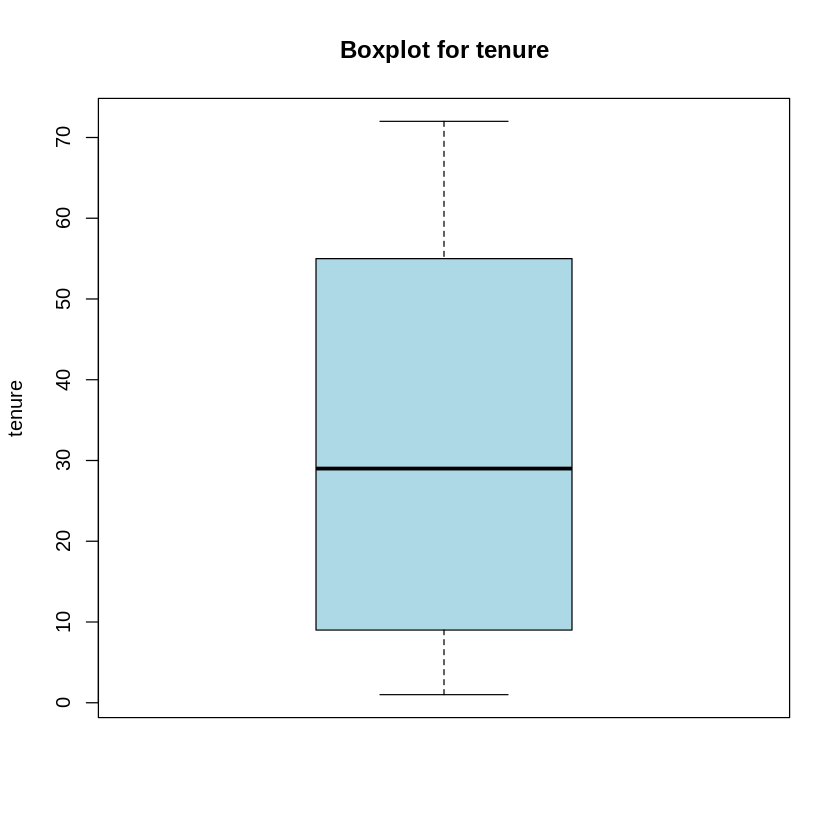

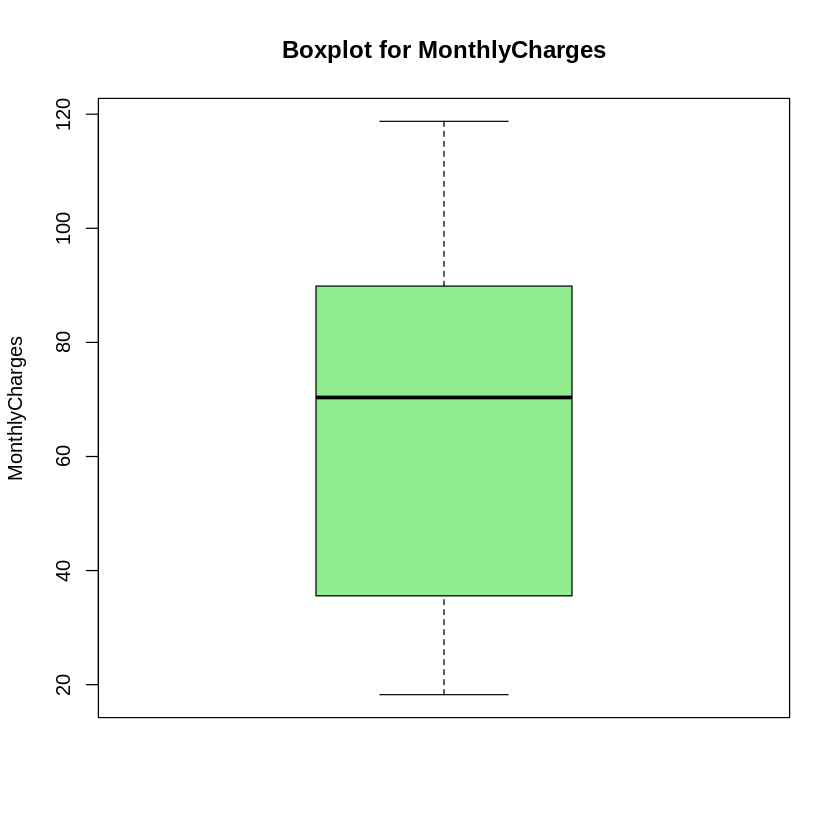

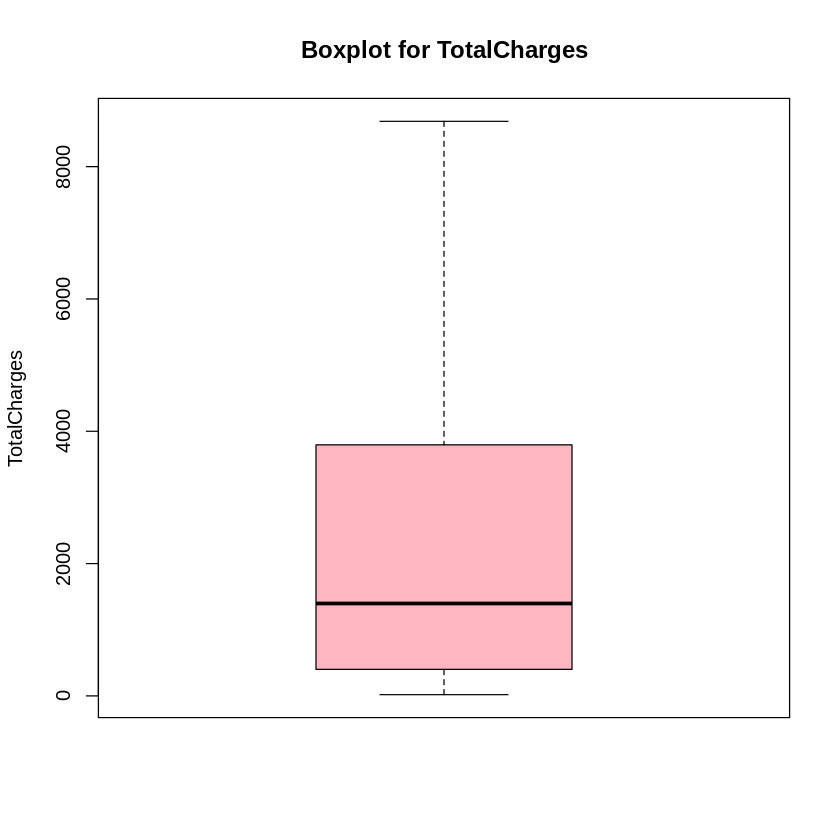

In [ ]:
# 1. 가입 기간(tenure) 박스플롯
boxplot(telco$tenure,
        main="Boxplot for tenure",
        ylab="tenure",
        col="lightblue")

# 2. 월 요금(MonthlyCharges) 박스플롯
boxplot(telco$MonthlyCharges,
        main="Boxplot for MonthlyCharges",
        ylab="MonthlyCharges",
        col="lightgreen")

# 3. 총 요금(TotalCharges) 박스플롯
boxplot(telco$TotalCharges,
        main="Boxplot for TotalCharges",
        ylab="TotalCharges",
        col="lightpink")

In [ ]:
par(mfrow=c(1,1))

# 5. 데이터 스케일링

In [ ]:
telco$tenure <- as.numeric(scale(telco$tenure))
telco$MonthlyCharges <- as.numeric(scale(telco$MonthlyCharges))
telco$TotalCharges <- as.numeric(scale(telco$TotalCharges))

# 카이제곱 검정 : Churn(이탈여부)와 Contract(계약형태) 관계

In [ ]:
CrossTable(telco$Churn, telco$Contract, chisq = TRUE)


 
   Cell Contents
|-------------------------|
|                       N |
| Chi-square contribution |
|           N / Row Total |
|           N / Col Total |
|         N / Table Total |
|-------------------------|

 
Total Observations in Table:  7032 

 
             | telco$Contract 
 telco$Churn | Month-to-month |       One year |       Two year |      Row Total | 
-------------|----------------|----------------|----------------|----------------|
          No |           2220 |           1306 |           1637 |           5163 | 
             |        137.335 |         46.940 |        129.231 |                | 
             |          0.430 |          0.253 |          0.317 |          0.734 | 
             |          0.573 |          0.887 |          0.972 |                | 
             |          0.316 |          0.186 |          0.233 |                | 
-------------|----------------|----------------|----------------|----------------|
         Yes |           1655 |          

# 데이터 분할 (Train / Test)

In [ ]:
# Churn 변수 Factor 변환
telco$Churn <- as.factor(telco$Churn)


set.seed(42)
train_idx <- createDataPartition(telco$Churn, p = 0.75, list = FALSE)

train_telco_raw <- telco[train_idx, ]
test_telco_raw <- telco[-train_idx, ]

preprocess_model <- preProcess(train_telco_raw, method = c("center", "scale"))

train_telco <- predict(preprocess_model, train_telco_raw)
test_telco  <- predict(preprocess_model, test_telco_raw)

`geom_smooth()` using formula = 'y ~ x'


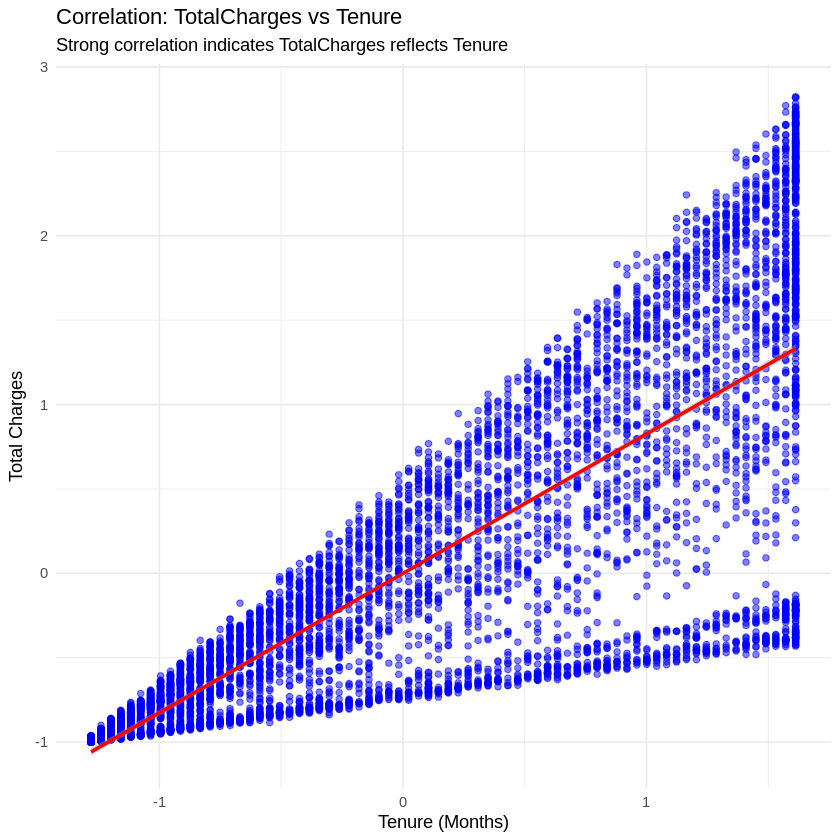

In [ ]:
library(ggplot2)

ggplot(telco, aes(x = tenure, y = TotalCharges)) +
  geom_point(alpha = 0.5, color = "blue") +
  geom_smooth(method = "lm", color = "red") +
  labs(title = "Correlation: TotalCharges vs Tenure",
       subtitle = "Strong correlation indicates TotalCharges reflects Tenure",
       x = "Tenure (Months)",
       y = "Total Charges") +
  theme_minimal()

# **로지스틱 회귀(Logistic Regression)**

# 로지스틱 회귀 모델 생성

In [ ]:
# TotalCharges는 MonthlyCharges * tenure와 강한 상관관계가 있어 다중공선성을 유발, 제외(-TotalCharges)
lorm_telco <- glm(Churn ~ . -TotalCharges, family = "binomial", data = train_telco)

# 변수 선택 (Backward)

In [ ]:
lorm_bw_telco <- step(lorm_telco, direction = "backward", trace = 0)
summary(lorm_bw_telco)


Call:
glm(formula = Churn ~ SeniorCitizen + Dependents + tenure + MultipleLines + 
    InternetService + OnlineSecurity + TechSupport + StreamingTV + 
    StreamingMovies + Contract + PaperlessBilling + PaymentMethod, 
    family = "binomial", data = train_telco)

Coefficients: (4 not defined because of singularities)
                                     Estimate Std. Error z value Pr(>|z|)    
(Intercept)                          -1.90980    0.15617 -12.229  < 2e-16 ***
SeniorCitizen                         0.08016    0.03588   2.234 0.025489 *  
DependentsYes                        -0.18071    0.09437  -1.915 0.055504 .  
tenure                               -0.87999    0.06342 -13.876  < 2e-16 ***
MultipleLinesNo phone service         0.49430    0.14695   3.364 0.000769 ***
MultipleLinesYes                      0.28667    0.09069   3.161 0.001573 ** 
InternetServiceFiber optic            0.87885    0.10500   8.370  < 2e-16 ***
InternetServiceNo                    -0.81332    0.1582

# 로지스틱 회귀 예측 수행

In [ ]:
predict_value <- predict(lorm_bw_telco, newdata = test_telco, type = "response") %>% as_tibble()

# 실제값과 예측값 결합

In [ ]:
real_predict <- bind_cols(test_telco %>% select(Churn), predict_value)
colnames(real_predict) <- c("Churn", "predict_value")

# 예측값에 포함된 NA 제거

In [ ]:
real_predict <- na.omit(real_predict)

# ROC 곡선 및 최적 Cut-off 찾기

In [ ]:
# Train 데이터에 대한 예측 수행 (Cut-off 도출용)
train_pred_value <- predict(lorm_bw_telco, newdata = train_telco, type = "response")
pred_obj_train <- prediction(train_pred_value, train_telco$Churn)

In [ ]:
# Accuracy가 최대가 되는 지점 찾기
acc_perf <- performance(pred_obj_train, measure = "acc")
ind <- which.max(slot(acc_perf, "y.values")[[1]])
roc_cutoff_value <- slot(acc_perf, "x.values")[[1]][ind]

In [ ]:
print(paste("Train 데이터로 도출된 최적 Cut-off Value:", roc_cutoff_value))

[1] "Train 데이터로 도출된 최적 Cut-off Value: 0.559674866918275"


In [ ]:
# Test 데이터 예측
test_pred_value <- predict(lorm_bw_telco, newdata = test_telco, type = "response") %>% as_tibble()

In [ ]:
# Test 데이터와 결합
real_predict <- bind_cols(test_telco %>% select(Churn), test_pred_value)
colnames(real_predict) <- c("Churn", "predict_value")

In [ ]:
# Cut-off 적용
real_predict <- real_predict %>%
  mutate(predict_Churn_roccut = as.factor(ifelse(predict_value > roc_cutoff_value, "Yes", "No")))

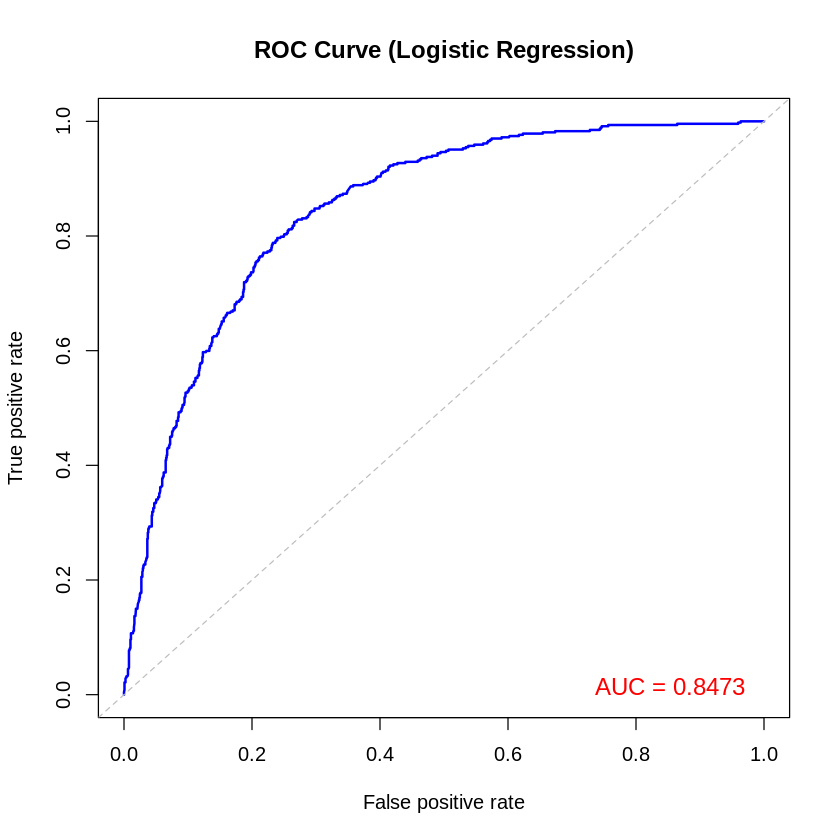

In [ ]:
# ROC 곡선 그리기
pred_roc <- prediction(real_predict$predict_value, real_predict$Churn)
perf_roc <- performance(pred_roc, measure = "tpr", x.measure = "fpr")
plot(perf_roc,
     main = "ROC Curve (Logistic Regression)",
     col = "blue",
     lwd = 2)

abline(a = 0, b = 1, lty = 2, col = "gray")

auc_perf <- performance(pred_roc, measure = "auc")
auc_score <- round(auc_perf@y.values[[1]], 4)

legend("bottomright",
       legend = paste("AUC =", auc_score),
       col = "red", bty = "n", cex = 1.2, text.col = "red")

# **로지스틱 회귀 평가**

In [ ]:
print("로지스틱 회귀 성능 평가")
confusionMatrix(real_predict$predict_Churn_roccut, real_predict$Churn, positive = "Yes")

[1] "로지스틱 회귀 성능 평가"


Confusion Matrix and Statistics

          Reference
Prediction   No  Yes
       No  1193  253
       Yes   97  214
                                          
               Accuracy : 0.8008          
                 95% CI : (0.7813, 0.8192)
    No Information Rate : 0.7342          
    P-Value [Acc > NIR] : 4.581e-11       
                                          
                  Kappa : 0.4287          
                                          
 Mcnemar's Test P-Value : < 2.2e-16       
                                          
            Sensitivity : 0.4582          
            Specificity : 0.9248          
         Pos Pred Value : 0.6881          
         Neg Pred Value : 0.8250          
             Prevalence : 0.2658          
         Detection Rate : 0.1218          
   Detection Prevalence : 0.1770          
      Balanced Accuracy : 0.6915          
                                          
       'Positive' Class : Yes             
                        

# **의사결정나무 (Decision Tree)**

In [ ]:
dt_model <- rpart(Churn ~ ., data = train_telco, method = "class")

#의사결정나무 시각화

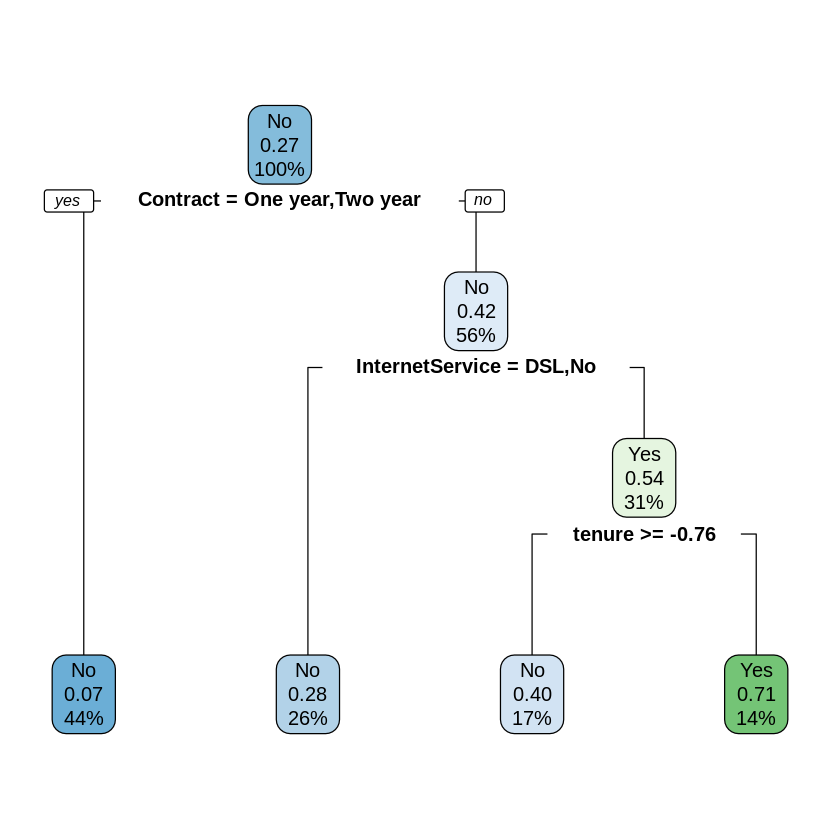

In [ ]:
rpart.plot(dt_model)

# 의사결정나무 예측 수행

In [ ]:
dt_pred <- predict(dt_model, newdata = test_telco, type = "class")

# 의사결정나무 성능 평가

In [ ]:
print("의사결정나무 성능 평가")
confusionMatrix(dt_pred, test_telco$Churn, positive = "Yes")

[1] "의사결정나무 성능 평가"


Confusion Matrix and Statistics

          Reference
Prediction   No  Yes
       No  1215  305
       Yes   75  162
                                          
               Accuracy : 0.7837          
                 95% CI : (0.7637, 0.8028)
    No Information Rate : 0.7342          
    P-Value [Acc > NIR] : 9.245e-07       
                                          
                  Kappa : 0.3426          
                                          
 Mcnemar's Test P-Value : < 2.2e-16       
                                          
            Sensitivity : 0.3469          
            Specificity : 0.9419          
         Pos Pred Value : 0.6835          
         Neg Pred Value : 0.7993          
             Prevalence : 0.2658          
         Detection Rate : 0.0922          
   Detection Prevalence : 0.1349          
      Balanced Accuracy : 0.6444          
                                          
       'Positive' Class : Yes             
                        

# **랜덤 포레스트 (Random Forest) : 가설 검증용**

# 랜덤 포레스트 모델링 및 가설 검증


In [ ]:
train_telco_clean <- na.omit(train_telco)
print(paste("NA :", sum(is.na(train_telco_clean))))

[1] "NA : 0"


In [ ]:
set.seed(42)
rf_model <- randomForest(Churn ~ ., data = train_telco_clean, importance = TRUE, ntree = 100)

# 랜덤 포레스트 예측 수행

In [ ]:
rf_pred <- predict(rf_model, newdata = test_telco)

# 랜덤 포레스트 성능 평가

In [ ]:
print("랜덤 포레스트 성능 평가")
confusionMatrix(rf_pred, test_telco$Churn, positive = "Yes")

[1] "랜덤 포레스트 성능 평가"


Confusion Matrix and Statistics

          Reference
Prediction   No  Yes
       No  1177  248
       Yes  113  219
                                          
               Accuracy : 0.7945          
                 95% CI : (0.7749, 0.8132)
    No Information Rate : 0.7342          
    P-Value [Acc > NIR] : 2.472e-09       
                                          
                  Kappa : 0.4201          
                                          
 Mcnemar's Test P-Value : 1.756e-12       
                                          
            Sensitivity : 0.4690          
            Specificity : 0.9124          
         Pos Pred Value : 0.6596          
         Neg Pred Value : 0.8260          
             Prevalence : 0.2658          
         Detection Rate : 0.1246          
   Detection Prevalence : 0.1890          
      Balanced Accuracy : 0.6907          
                                          
       'Positive' Class : Yes             
                        

# 변수 중요도 시각화 (가설 검증)

In [ ]:
importance_df <- as.data.frame(importance(rf_model))
importance_df$Feature <- rownames(importance_df)

#중요도 순으로 정렬

In [ ]:
top_features <- importance_df %>%
  arrange(desc(MeanDecreaseGini)) %>%
  head(10)

#시각화

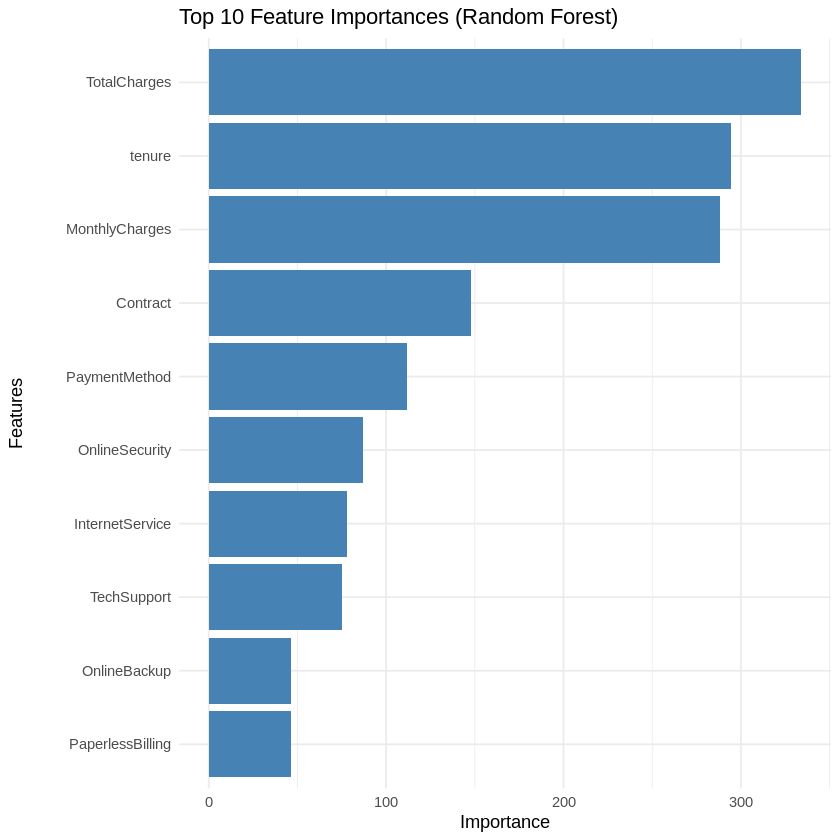

In [ ]:
ggplot(top_features, aes(x = reorder(Feature, MeanDecreaseGini), y = MeanDecreaseGini)) +
  geom_bar(stat = "identity", fill = "steelblue") +
  coord_flip() +
  labs(title = "Top 10 Feature Importances (Random Forest)",
       x = "Features", y = "Importance") +
  theme_minimal()

# 신규 데이터 예측

In [ ]:
new_customer <- train_telco[1, ]
new_customer$tenure <- 1.5 # 스케일링된 값
new_customer$Contract <- factor("Month-to-month", levels = levels(telco$Contract))
new_customer$MonthlyCharges <- 1.5

new_pred_prob <- predict(lorm_bw_telco, newdata = new_customer, type = "response")
new_pred_result <- ifelse(new_pred_prob > roc_cutoff_value, "Yes", "No")

print(paste("신규 고객 이탈 예측 결과:", new_pred_result))

[1] "신규 고객 이탈 예측 결과: No"


#감사합니다 :)

#발표 이후 추가 코드

In [ ]:
install.packages("corrplot") # 상관관계 시각화용
install.packages("gridExtra") # 그래프 배치용

library(corrplot)
library(gridExtra)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

corrplot 0.95 loaded


Attaching package: ‘gridExtra’


The following object is masked from ‘package:randomForest’:

    combine


The following object is masked from ‘package:dplyr’:

    combine




데이터 불균형 처리
- 샘플링 기법을 사용하여 학습 데이터 내부에서 잔존과 이탈의 비율을 강제로 50:50으로 맞춰 모델을 다시 만들어보고 성능 확인.

In [ ]:
# 기존 Train 데이터를 사용하여 다운 샘플링을 실행하고 비율을 1:1로 맞춰 성능확인
set.seed(42)
train_balanced <- downSample(x = train_telco[, -which(names(train_telco) == "Churn")],
                             y = train_telco$Churn)
names(train_balanced)[names(train_balanced) == "Class"] <- "Churn"

# 균형 확인
print("샘플링 전 Train 데이터 비율 ")
print(table(train_telco$Churn))
print("샘플링 후 Train 데이터 비율")
print(table(train_balanced$Churn))

# 랜덤 포레스트 모델 재학습
set.seed(42)
rf_model_balanced <- randomForest(Churn ~ .,
                                  data = train_balanced,
                                  importance = TRUE,
                                  ntree = 100)

# 예측 수행 (현실 반영을 위해 test 데이터는 그대로 사용하였습니다!)
rf_pred_balanced <- predict(rf_model_balanced, newdata = test_telco)

# 성능 비교 평가
print("랜덤 포레스트 (불균형 데이터 학습) ")
confusionMatrix(rf_pred, test_telco$Churn, positive = "Yes")

print("랜덤 포레스트 (50:50 데이터 학습)")
confusionMatrix(rf_pred_balanced, test_telco$Churn, positive = "Yes")

[1] "샘플링 전 Train 데이터 비율 "

  No  Yes 
3873 1402 
[1] "샘플링 후 Train 데이터 비율"

  No  Yes 
1402 1402 
[1] "랜덤 포레스트 (불균형 데이터 학습) "


Confusion Matrix and Statistics

          Reference
Prediction   No  Yes
       No  1177  248
       Yes  113  219
                                          
               Accuracy : 0.7945          
                 95% CI : (0.7749, 0.8132)
    No Information Rate : 0.7342          
    P-Value [Acc > NIR] : 2.472e-09       
                                          
                  Kappa : 0.4201          
                                          
 Mcnemar's Test P-Value : 1.756e-12       
                                          
            Sensitivity : 0.4690          
            Specificity : 0.9124          
         Pos Pred Value : 0.6596          
         Neg Pred Value : 0.8260          
             Prevalence : 0.2658          
         Detection Rate : 0.1246          
   Detection Prevalence : 0.1890          
      Balanced Accuracy : 0.6907          
                                          
       'Positive' Class : Yes             
                        

[1] "랜덤 포레스트 (50:50 데이터 학습)"


Confusion Matrix and Statistics

          Reference
Prediction  No Yes
       No  971 108
       Yes 319 359
                                          
               Accuracy : 0.757           
                 95% CI : (0.7362, 0.7769)
    No Information Rate : 0.7342          
    P-Value [Acc > NIR] : 0.01582         
                                          
                  Kappa : 0.4558          
                                          
 Mcnemar's Test P-Value : < 2e-16         
                                          
            Sensitivity : 0.7687          
            Specificity : 0.7527          
         Pos Pred Value : 0.5295          
         Neg Pred Value : 0.8999          
             Prevalence : 0.2658          
         Detection Rate : 0.2043          
   Detection Prevalence : 0.3859          
      Balanced Accuracy : 0.7607          
                                          
       'Positive' Class : Yes             
                              

변수 간 상관관계 분석표

                  tenure MonthlyCharges TotalCharges
tenure         1.0000000      0.2468618    0.8258805
MonthlyCharges 0.2468618      1.0000000    0.6510648
TotalCharges   0.8258805      0.6510648    1.0000000


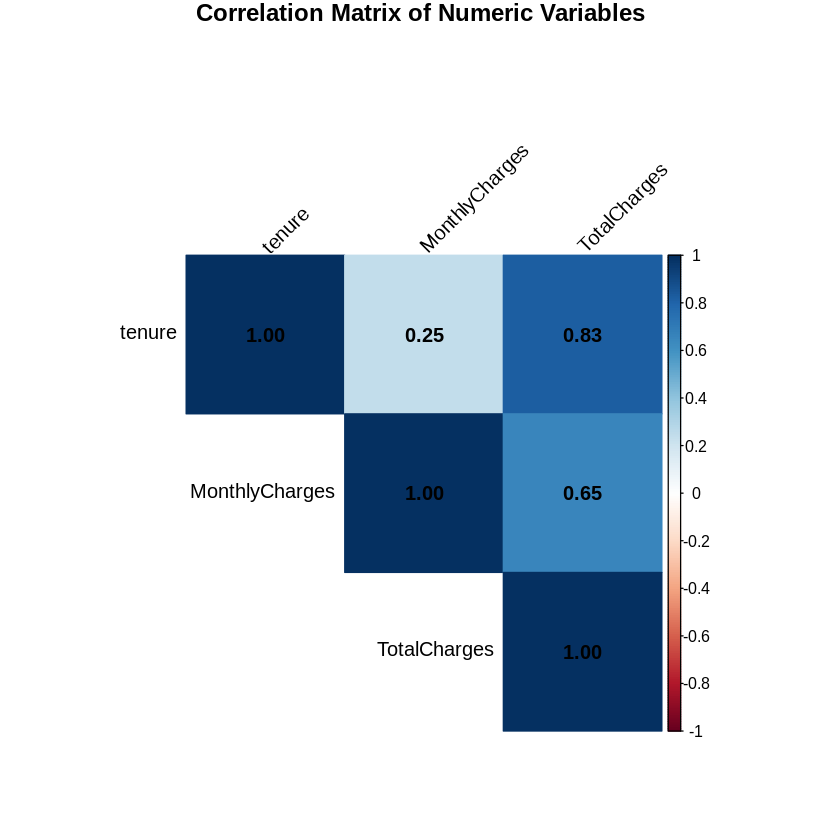

In [ ]:
# tenure, MonthlyCharges, TotalCharges 선택
numeric_vars <- telco %>% select(tenure, MonthlyCharges, TotalCharges)

# 상관계수 계산
cor_matrix <- cor(numeric_vars)

# 상관관계표 출력
print(cor_matrix)

# 상관관계 시각화
corrplot(cor_matrix,
         method = "color",
         type = "upper",
         addCoef.col = "black",
         tl.col = "black",
         tl.srt = 45,
         title = "Correlation Matrix of Numeric Variables",
         mar = c(0,0,1,0))

추가 데이터 시각화
- Density Plot, Stacked Bar Chart 사용

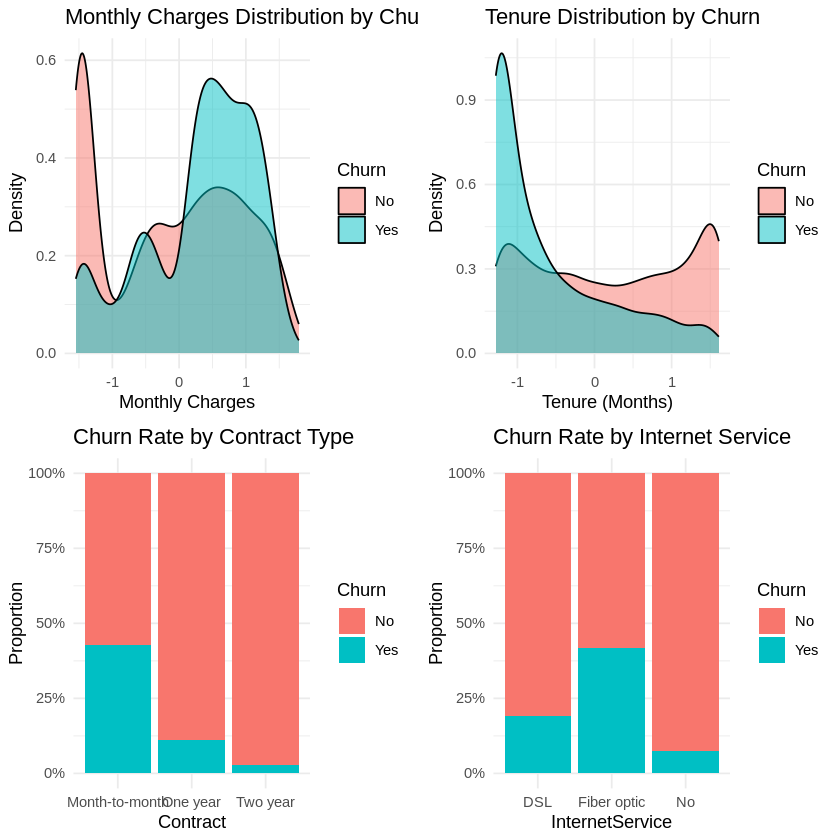

In [ ]:
# 이탈 여부에 따른 월 요금 분포 (density plot)
p1 <- ggplot(telco, aes(x = MonthlyCharges, fill = Churn)) +
  geom_density(alpha = 0.5) +
  labs(title = "Monthly Charges Distribution by Churn", x = "Monthly Charges", y = "Density") +
  theme_minimal()

# 이탈 여부에 따른 가입 기간 분포 (density plot)
p2 <- ggplot(telco, aes(x = tenure, fill = Churn)) +
  geom_density(alpha = 0.5) +
  labs(title = "Tenure Distribution by Churn", x = "Tenure (Months)", y = "Density") +
  theme_minimal()

# 계약 형태(Contract)별 이탈 비율 (stacked bar chart)
p3 <- ggplot(telco, aes(x = Contract, fill = Churn)) +
  geom_bar(position = "fill") +
  labs(title = "Churn Rate by Contract Type", y = "Proportion") +
  theme_minimal() +
  scale_y_continuous(labels = scales::percent)

# 인터넷 서비스(InternetService)별 이탈 비율
p4 <- ggplot(telco, aes(x = InternetService, fill = Churn)) +
  geom_bar(position = "fill") +
  labs(title = "Churn Rate by Internet Service", y = "Proportion") +
  theme_minimal() +
  scale_y_continuous(labels = scales::percent)

# 그래프 4개를 한 화면에 출력
grid.arrange(p1, p2, p3, p4, ncol = 2)

#시각화 추가
# K-Fold CV, Grid Search, Lift Chart


[1] ">>> 하이퍼파라미터 튜닝 및 교차 검증 시작 (시간이 조금 걸립니다...) <<<"
Random Forest 

2804 samples
  19 predictor
   2 classes: 'No', 'Yes' 

No pre-processing
Resampling: Cross-Validated (5 fold) 
Summary of sample sizes: 2244, 2243, 2243, 2244, 2242 
Resampling results across tuning parameters:

  mtry  ROC        Sens       Spec     
  2     0.8373958  0.7032867  0.8145247
  4     0.8436735  0.7275419  0.7981368
  6     0.8385339  0.7489324  0.7753432
  8     0.8348811  0.7425165  0.7660676

ROC was used to select the optimal model using the largest value.
The final value used for the model was mtry = 4.


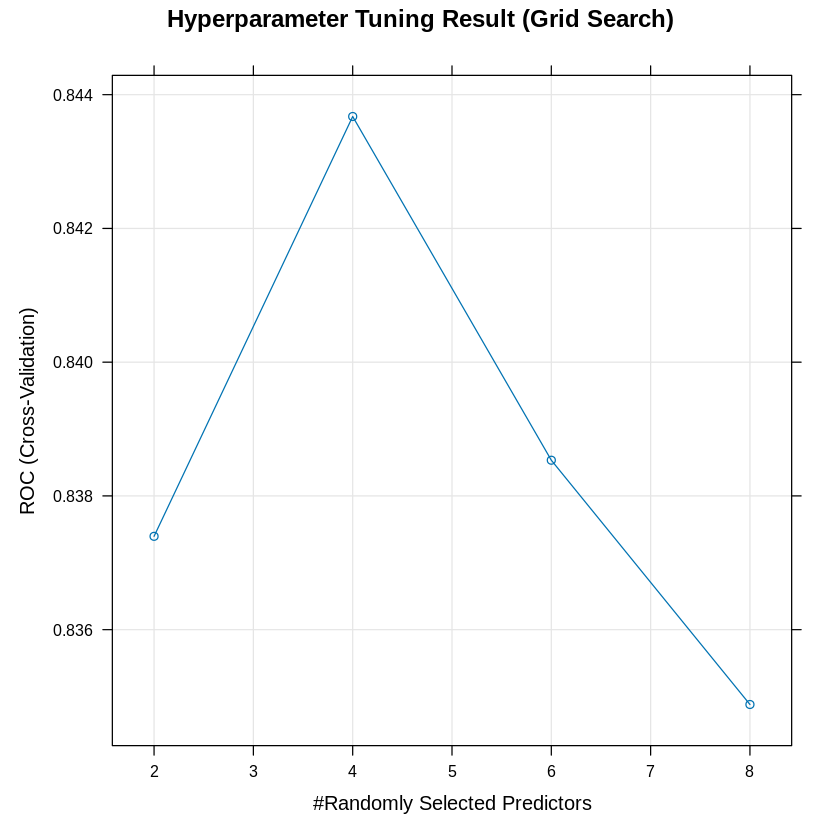

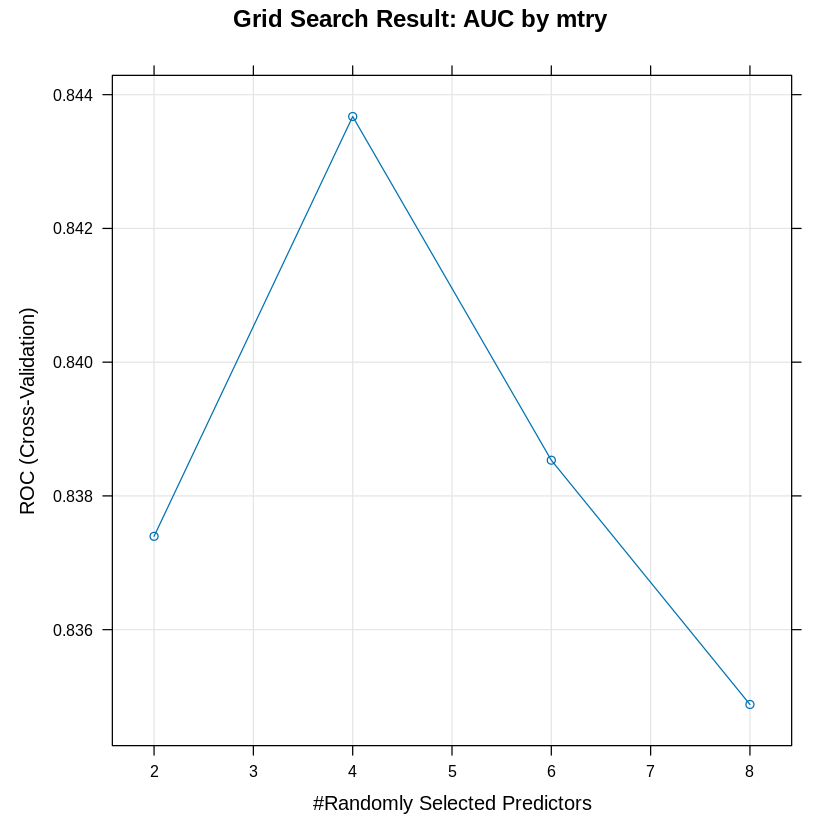

[1] "평균 AUC: 0.8437"


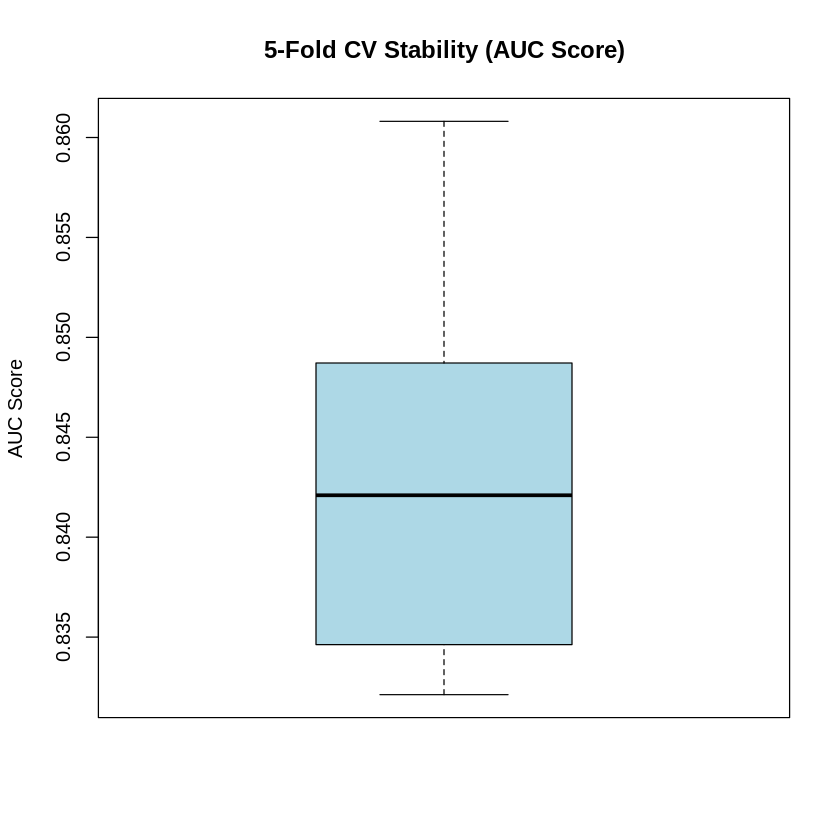

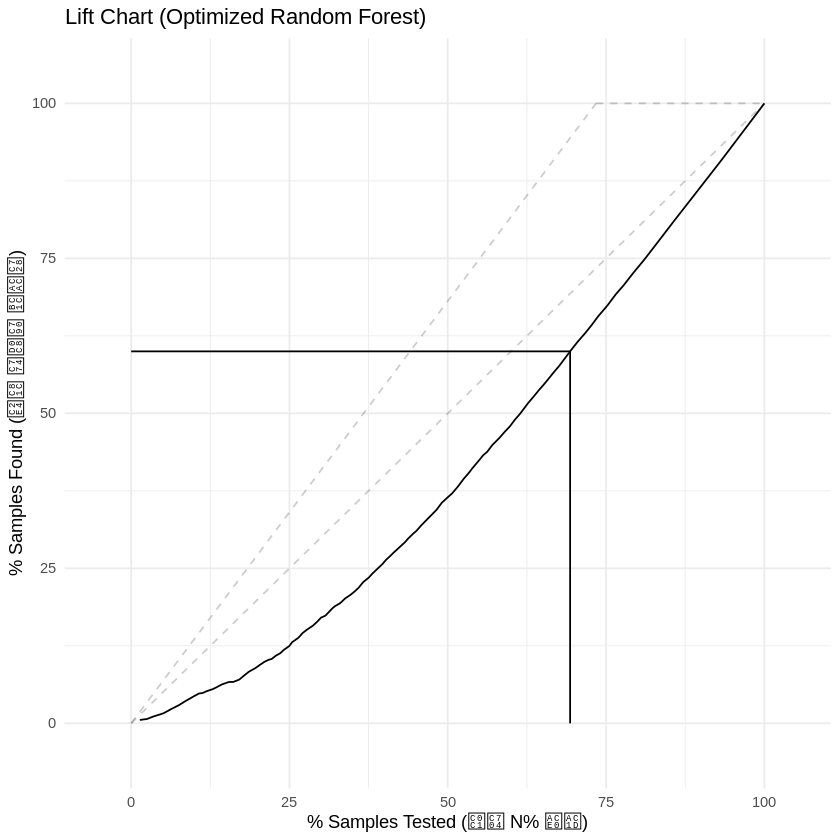

In [ ]:


library(caret)
library(ggplot2)



ctrl <- trainControl(method = "cv",
                     number = 5,
                     classProbs = TRUE,
                     summaryFunction = twoClassSummary,
                     savePredictions = "all")

rf_grid <- expand.grid(mtry = c(2, 4, 6, 8))

print(">>> 하이퍼파라미터 튜닝 및 교차 검증 시작 (시간이 조금 걸립니다...) <<<")

# 3. 모델 학습
set.seed(42)
rf_tuned <- train(Churn ~ .,
                  data = train_balanced, # 50:50 샘플링된 데이터 사용
                  method = "rf",
                  trControl = ctrl,
                  tuneGrid = rf_grid,
                  metric = "ROC", # AUC가 가장 높은 파라미터 선택
                  ntree = 100)

# 4. 튜닝 결과 확인
print(rf_tuned)
plot(rf_tuned, main = "Hyperparameter Tuning Result (Grid Search)")

#하이퍼파라미터 튜닝 결과

# mtry 값 변화에 따른 ROC(AUC) 성능 변화
plot(rf_tuned, main = "Grid Search Result: AUC by mtry")

# [시각화 2] 5-Fold 교차 검증 안정성 확인

# 상자 크기가 작을수록 모델이 안정적
boxplot(rf_tuned$resample$ROC,
        main = "5-Fold CV Stability (AUC Score)",
        col = "lightblue",
        ylab = "AUC Score")

# 평균 점수 출력
print(paste("평균 AUC:", round(mean(rf_tuned$resample$ROC), 4)))

# 향상도 차트 (Lift Chart)

# Test 데이터에 대한 예측 확률 계산
rf_prob_test <- predict(rf_tuned, newdata = test_telco, type = "prob")

# 데이터 결합 (실제값 + 예측확률)
lift_data <- data.frame(Class = test_telco$Churn,
                        Yes = rf_prob_test$Yes)

lift_obj <- caret::lift(Class ~ Yes, data = lift_data)

# Lift Chart
# 파란 선이 회색 대각선보다 위로 볼록한 것을 보면, 마케팅 효율이 좋다는 것을 알 수 있음.
ggplot(lift_obj, values = 60) +
  ggtitle("Lift Chart (Optimized Random Forest)") +
  theme_minimal() +
  labs(x = "% Samples Tested (상위 N% 고객)",
       y = "% Samples Found (실제 이탈자 발견율)")